# Loading the Data

In [1]:
from keras.datasets import mnist
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [2]:
type(x_train)

numpy.ndarray

## Segmenting the Y to Seven Segment display

In [72]:
def seven_segment_output(x):
    if x ==  0:
        return 	np.array([1,1,1,1,1,1,0])
    elif x == 1:
    	return np.array([0,1,1,0,0,0,0])
    elif x == 2:
    	return np.array([1,1,0,1,1,0,1])
    elif x == 3:
    	return np.array([1,1,1,1,0,0,1])
    elif x == 4:
    	return np.array([0,1,1,0,0,1,1])
    elif x == 5:
    	return np.array([1,0,1,1,0,1,1])
    elif x == 6:
    	return np.array([1,0,1,1,1,1,1])
    elif x == 7:
    	return np.array([1,1,1,0,0,1,0])
    elif x == 8:
    	return np.array([1,1,1,1,1,1,1])
    else:
    	return np.array([1,1,1,1,0,1,1])

## Function to get back the original label

In [73]:
def seven_segment_back(x):
    if x ==  [1,1,1,1,1,1,0]:
        return 0
    elif x == [0,1,1,0,0,0,0]:
    	return 1
    elif x == [1,1,0,1,1,0,1]:
    	return 2
    elif x == [1,1,1,1,0,0,1]:
    	return 3
    elif x == [0,1,1,0,0,1,1]:
    	return 4
    elif x == [1,0,1,1,0,1,1]:
    	return 5
    elif x == [1,0,1,1,1,1,1]:
    	return 6
    elif x == [1,1,1,0,0,1,0]:
    	return 7
    elif x == [1,1,1,1,1,1,1]:
    	return 8
    elif x == [1,1,1,1,0,1,1]:
    	return 9
    else:
        return 101

### Segmenting the Y_train and y_Test

In [4]:
y_train_segmented = np.array(list(map(seven_segment_output,y_train)))

In [5]:
y_train_segmented.shape

(60000, 7)

In [6]:
y_test_segmented = np.array(list(map(seven_segment_output,y_test)))

In [7]:
y_test_segmented.shape

(10000, 7)

## Normalizing the data

In [8]:
x_train = np.reshape(x_train,(len(x_train),28,28,1))
x_test = np.reshape(x_test,(len(x_test),28,28,1))

In [9]:
x_train.shape[1:]

(28, 28, 1)

In [10]:
y_train[1:10]

array([0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

## Encoding the data

In [11]:
import keras
from keras import layers
import tensorflow_addons as tfa

C:\Users\Harisarvothama\.conda\envs\py310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
C:\Users\Harisarvothama\.conda\envs\py310\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an 

In [15]:
input_img = keras.Input(shape=x_train.shape[1:])
x = layers.Conv2D(16,(3,3),activation='relu',padding='same')(input_img)
x = layers.MaxPool2D((2,2),  padding='same')(x)
x = layers.Conv2D(8,(3,3),activation='relu',padding='same')(x)
x = layers.MaxPool2D((2,2),  padding='same')(x)
x = layers.Conv2D(8,(3,3),activation='relu',padding='same')(x)
encoded = layers.MaxPool2D((2,2),  padding='same')(x)

#encoding done

#decoding starts
x = layers.Conv2D(8,(3,3),activation='relu',padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(8,(3,3),activation='relu',padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(16,(3,3),activation='relu')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img,decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_14 (Conv2D)          (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 14, 14, 16)       0         
 2D)                                                             
                                                                 
 conv2d_15 (Conv2D)          (None, 14, 14, 8)         1160      
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 7, 7, 8)          0         
 2D)                                                             
                                                                 
 conv2d_16 (Conv2D)          (None, 7, 7, 8)           584 

In [16]:
history = autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 [==============================] - 7s 8ms/step - loss: 0.2577 - val_loss: 0.1678
Epoch 2/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1547 - val_loss: 0.1442
Epoch 3/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1390 - val_loss: 0.1321
Epoch 4/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1294 - val_loss: 0.1247
Epoch 5/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1234 - val_loss: 0.1197
Epoch 6/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1189 - val_loss: 0.1164
Epoch 7/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1156 - val_loss: 0.1129
Epoch 8/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1132 - val_loss: 0.1112
Epoch 9/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1114 - val_loss: 0.1097
Epoch 10/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1099 - val_loss: 0.1081

### Decoding the data

In [17]:
decoded_imgs_train = autoencoder.predict(x_train)

1875/1875 [==============================] - 2s 1ms/step


In [18]:
decoded_imgs_train.shape

(60000, 28, 28, 1)

In [19]:
decoded_imgs_test = autoencoder.predict(x_test)

313/313 [==============================] - 0s 1ms/step


In [20]:
decoded_imgs_test.shape

(10000, 28, 28, 1)

## Running the Encoded data with the CNN multi lable classification

In [21]:
from sklearn.model_selection import train_test_split
X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(decoded_imgs_train, y_train_segmented, test_size=0.3, random_state=42)

In [22]:
from keras import backend as K

def full_multi_label_metric(y_true, y_pred):
    comp = K.equal(y_true, K.round(y_pred))
    return K.cast(K.all(comp, axis=-1), K.floatx())

In [38]:
import tensorflow as tf

In [84]:
input_img = keras.Input(shape=X_train_model.shape[1:])
x = layers.Conv2D(16,(3,3),activation='relu',padding='same')(input_img)
x = layers.MaxPool2D((2,2),  padding='same')(x)
x = layers.Conv2D(8,(3,3),activation='relu',padding='same')(x)
x = layers.Flatten()(x)
y = layers.Dense(512,activation='relu')(x)
y = layers.Dense(32,activation='relu')(y)
y = layers.Dense(7,activation='sigmoid')(y)

model = keras.Model(input_img,y)

In [85]:
# Compile the model with optimizer, loss function, and metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy', 
        tf.keras.metrics.Precision(name='precision')]
)

# Print the model summary
model.summary()

Model: "model_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_39 (Conv2D)          (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d_18 (MaxPoolin  (None, 14, 14, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_40 (Conv2D)          (None, 14, 14, 8)         1160      
                                                                 
 flatten_8 (Flatten)         (None, 1568)              0         
                                                                 
 dense_29 (Dense)            (None, 512)               803328    
                                                          

In [86]:
history_mlp = model.fit(X_train_model,y_train_model,batch_size=64,epochs=10
                        ,shuffle=True,validation_data=(X_test_model,y_test_model))

Epoch 1/10
657/657 [==============================] - 3s 4ms/step - loss: 0.0977 - accuracy: 0.2182 - precision: 0.9680 - val_loss: 0.0470 - val_accuracy: 0.2713 - val_precision: 0.9865
Epoch 2/10
657/657 [==============================] - 2s 4ms/step - loss: 0.0417 - accuracy: 0.2429 - precision: 0.9889 - val_loss: 0.0376 - val_accuracy: 0.2587 - val_precision: 0.9884
Epoch 3/10
657/657 [==============================] - 3s 4ms/step - loss: 0.0312 - accuracy: 0.2428 - precision: 0.9917 - val_loss: 0.0324 - val_accuracy: 0.2731 - val_precision: 0.9927
Epoch 4/10
657/657 [==============================] - 3s 4ms/step - loss: 0.0247 - accuracy: 0.2818 - precision: 0.9935 - val_loss: 0.0293 - val_accuracy: 0.2842 - val_precision: 0.9925
Epoch 5/10
657/657 [==============================] - 3s 4ms/step - loss: 0.0203 - accuracy: 0.3102 - precision: 0.9947 - val_loss: 0.0305 - val_accuracy: 0.2413 - val_precision: 0.9935
Epoch 6/10
657/657 [==============================] - 3s 4ms/step - lo

#### Predicting the output

In [87]:
y_pred = model.predict(decoded_imgs_test)

313/313 [==============================] - 0s 1ms/step


In [89]:
y_pred[1]

array([1.0000000e+00, 1.0000000e+00, 5.2138259e-11, 1.0000000e+00,
       1.0000000e+00, 1.2549177e-11, 1.0000000e+00], dtype=float32)

#### Creating the threshold for the values to get binary values

In [91]:
y_pred_binary = (y_pred > 0.5).astype(int)

In [97]:
list(y_pred_binary[1])

[1, 1, 0, 1, 1, 0, 1]

#### Denormalizing the outputs [1,1,0,1,1,0,1] to 2 

In [98]:
y_pred_normal = []
for i in range(len(y_pred_binary)):
    y_pred_normal.append(seven_segment_back(list(y_pred_binary[i])))

In [99]:
y_pred_normal[1:10]

[2, 1, 0, 4, 1, 101, 9, 5, 9]

In [101]:
y_test[1:10]

array([2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

### Getting the Accuracy Scores

In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [106]:
# Compute metrics
accuracy = accuracy_score(y_test, y_pred_normal)
precision = precision_score(y_test, y_pred_normal,pos_label='positive', average='micro')
recall = recall_score(y_test, y_pred_normal,pos_label='positive', average='micro')
f1 = f1_score(y_test, y_pred_normal,pos_label='positive', average='micro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9645
Precision: 0.9645
Recall: 0.9645
F1 Score: 0.9645


C:\Users\Harisarvothama\.conda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1561: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\Harisarvothama\.conda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1561: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\Harisarvothama\.conda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1561: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


### Creating the Confusion Matrix

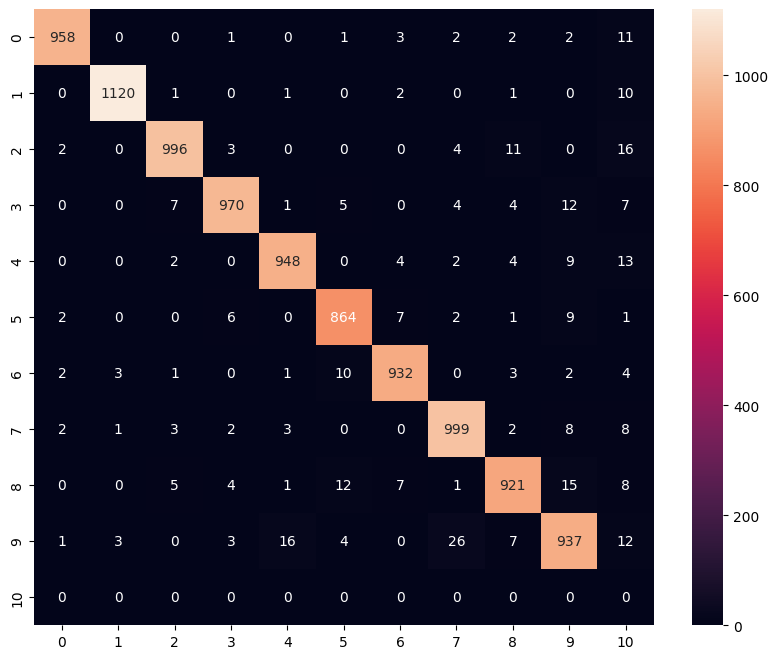

In [107]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cnfs_mtrx = confusion_matrix(y_test, y_pred_normal)

plt.figure(figsize=(10,8))
sns.heatmap(cnfs_mtrx, annot=True,fmt='d')
plt.show()